# IntPhys2 — Prediction-based Evaluation

## Surprisal formulation

Given a video $V$ of $N$ frames and a model handling $M < N$ frames, we form overlapping sliding windows of $M$ frames with stride $S$, giving windows starting at frames $0, S, 2S, \ldots, N{-}M$. Each window is split into a **context** of $C$ frames and a **target** of $T = M - C$ frames. The per-window surprise is:

$$\text{Surprise}_w = d\!\left(p\!\left(f(V_{w:w+C})\right),\; f'(V_{w+C:w+M})\right) \tag{1}$$

where $w$ is the window's starting frame, $d$ a distance measure, $f$ the encoder for the context, $f'$ the target encoder, and $p$ the predictor.

### V-JEPA 2

$$\text{Surprise}_w = d\!\left(p\!\left(f(V_{w:w+C})\right),\; \mathrm{LN}\!\left([f'(V_{w:w+M})]_T\right)\right)$$

- $f$ — V-JEPA 2 encoder (frozen ViT-H), applied to context patch tokens
- $f'$ — target encoder (EMA copy of $f$), applied to the **full** window; $[\cdot]_T$ selects the target patch positions $w{+}C \to w{+}M$
- $p$ — predictor (separate ViT), takes context encodings and mask tokens and predicts target-region representations
- $\mathrm{LN}$ — layer normalization over the feature dimension, applied to targets before computing $d$
- $d$ — mean L1 distance over all $N_T$ target tokens and feature dimension $D$:

$$d(\hat{z}, z) = \frac{1}{N_T \cdot D}\sum_{n=1}^{N_T}\sum_{d=1}^{D} |\hat{z}_{n,d} - z_{n,d}|$$

Surprise is measured in **representation space** (not pixel space). The EMA target encoder provides stable targets decoupled from the online encoder weights.

### VideoMAEv2

For VideoMAEv2, $f$ is the encoder, $f'$ is the **identity** (patch-normalized pixel values), and $p$ is the decoder — so surprise is measured directly in pixel space.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

# figures and computations


In [2]:
# ---------------------------------------------------------------------------
# Configuration — edit these before running
# ---------------------------------------------------------------------------

MODEL_NAME  = "vjepa2"          
# label used in plot titles and filenames
PTH_FOLDER  = "/data/kxzheng/models/checkpoint/vjepa-2-h/intphys_v2/intphys2-main-default"                
# path to folder containing losses_*.pth files
METADATA_CSV = "/data/kxzheng/data/IntPhys2/Main/metadata.csv"               
# path to metadata.csv for this split
DATASET     = "intphys2-main" # intphys2-debug | intphys2-main | intphys2-heldout

# Where to save figures (set to None to skip saving)
SAVE_DIR    = "./figures"

In [24]:
# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def load_pth_files(pth_folder, dataset):
    if dataset == "intphys2-main":
        files = sorted(glob.glob(os.path.join(pth_folder, "losses_*rank*.pth")))
    else:
        files = sorted(glob.glob(os.path.join(pth_folder, "losses_*.pth")))
        files = [f for f in files if "rank" not in os.path.basename(f)]
    if not files:
        raise FileNotFoundError(f"No .pth files found in {pth_folder}")
    all_losses, all_names, meta = [], [], None
    for f in files:
        data = torch.load(f, map_location="cpu", weights_only=False)
        if meta is None:
            meta = {k: v for k, v in data.items() if k not in ("losses", "names")}
        all_losses.append(data["losses"])
        all_names.extend(list(data["names"]))
    max_t = max(l.shape[2] for l in all_losses)
    padded = [torch.nn.functional.pad(l, (0, max_t - l.shape[2])) for l in all_losses]
    return torch.cat(padded, dim=0), all_names, meta   # [N, C, T]


def load_metadata(metadata_csv):
    df_gt_labels = pd.read_csv(metadata_csv)
    df_gt_labels["_basename"] = df_gt_labels["file_name"].apply(lambda x: os.path.basename(str(x)))
    df_gt_labels = df_gt_labels.rename(columns={'name': 'filename'})
    #predicted_labels.filename = predicted_labels.filename.astype(str)
    df_gt_labels.filename = df_gt_labels.filename.astype(str)
    return df_gt_labels

def label_target(row):
    if "Impossible" in row["type"]:
        return 0
    elif "Possible" in row["type"]:
        return 1
    else:
        print("Parsing Error!")

def aggregate_surprise(losses):
    """Mean L1 loss per video per context length, ignoring zero-padded frames.

    losses : Tensor [N_videos, N_ctx, T]
    returns: ndarray [N_videos, N_ctx]
    """
    mask = (losses > 0).float()
    scores = (losses * mask).sum(dim=2) / mask.sum(dim=2).clamp(min=1)
    return scores.numpy()   # [N_videos, N_ctx]

def build_results_df(losses, names, metadata_df):
    scores = aggregate_surprise(losses)         # [N_videos, N_ctx]
    name_to_idx = {n: i for i, n in enumerate(names)}
    df = metadata_df.copy()
    df["video_idx"] = df["_basename"].map(name_to_idx)
    df = df.dropna(subset=["video_idx"])
    df["video_idx"] = df["video_idx"].astype(int)
    # per-context scores as a list, max across contexts as the summary score
    df["surprise_scores"] = df["video_idx"].apply(lambda i: scores[i])       # [N_ctx]
    df["surprise_score"]  = df["surprise_scores"].apply(lambda s: s.max())   # scalar
    df["target"] = df.apply(label_target, axis=1).astype(int)
    return df

def compute_scene_accuracy(results_df, ctx_lengths):
    """Compute scene accuracy per context length, report max across context lengths.

    For each scene: correct_c = impossible mean surprise > possible mean surprise
    at context length c. Overall correct = max across context lengths.
    """
    rows = []
    for scene_idx, grp in results_df.groupby("SceneIndex"):
        possible   = grp[grp["target"] == 1]["surprise_scores"].tolist()
        impossible = grp[grp["target"] == 0]["surprise_scores"].tolist()
        if not possible or not impossible:
            continue
        pos_arr = np.stack(possible)    # [n_pos, N_ctx]
        imp_arr = np.stack(impossible)  # [n_imp, N_ctx]
        correct_per_ctx = (imp_arr.mean(0) > pos_arr.mean(0)).astype(int)  # [N_ctx]
        row = {
            "SceneIndex": scene_idx,
            "correct":    int(correct_per_ctx.max()),   # max across ctx lengths
            "condition":  grp["condition"].iloc[0],
            "env":        grp["env"].iloc[0],
            "Difficulty": grp["Difficulty"].iloc[0],
            "game_name":  grp["game_name"].iloc[0],
            "Camera":        grp["Camera"].iloc[0],
        }
        for c, ctx in enumerate(ctx_lengths):
            row[f"correct_ctx{ctx}"] = int(correct_per_ctx[c])
        rows.append(row)
    return pd.DataFrame(rows)


def savefig(fig, name):
    if SAVE_DIR is None:
        return
    os.makedirs(SAVE_DIR, exist_ok=True)
    path = os.path.join(SAVE_DIR, f"{MODEL_NAME}_{name}.png")
    fig.savefig(path, bbox_inches="tight")
    print(f"Saved: {path}")

In [25]:
# ---------------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------------

losses, names, meta = load_pth_files(PTH_FOLDER, DATASET)
metadata_df         = load_metadata(METADATA_CSV) # easy, medium, hard, + unknown split without metadata
results_df          = build_results_df(losses, names, metadata_df)
ctx_lengths         = meta.get("context_lengths", list(range(losses.shape[1])))
scene_acc           = compute_scene_accuracy(results_df,ctx_lengths)

In [26]:
results_df

,SceneIndex,filename,file_name,game_name,condition,env,type,occluder,Difficulty,Camera,_basename,video_idx,surprise_scores,surprise_score,target
0,0,083861b17a8b3f4bef7e3aaad0b960318a5ea19ca98258...,Videos/083861b17a8b3f4bef7e3aaad0b960318a5ea19...,FixedJumpSolidity,solidity,BasicLevel_0,1_Possible,NaN,Easy,Fixed,083861b17a8b3f4bef7e3aaad0b960318a5ea19ca98258...,261,"[0.68906003, 0.68414265, 0.6820445, 0.6806904,...",0.689060,1
1,0,56c044c79b791ff1d2eae592c3af1914772d79a23c9603...,Videos/56c044c79b791ff1d2eae592c3af1914772d79a...,FixedJumpSolidity,solidity,BasicLevel_0,1_Impossible,NaN,Easy,Fixed,56c044c79b791ff1d2eae592c3af1914772d79a23c9603...,599,"[0.69121546, 0.6863964, 0.6840023, 0.68226606,...",0.691215,0
2,0,4b2779c2649b64094af506b8783525387c2f7cd52dd8f5...,Videos/4b2779c2649b64094af506b8783525387c2f7cd...,FixedJumpSolidity,solidity,BasicLevel_0,2_Impossible,NaN,Easy,Fixed,4b2779c2649b64094af506b8783525387c2f7cd52dd8f5...,588,"[0.69043434, 0.6859206, 0.68376, 0.6822683, 0....",0.690434,0
3,0,66a6de26327fe7661ac4fec04da96d0710d2177afad8ba...,Videos/66a6de26327fe7661ac4fec04da96d0710d2177...,FixedJumpSolidity,solidity,BasicLevel_0,2_Possible,NaN,Easy,Fixed,66a6de26327fe7661ac4fec04da96d0710d2177afad8ba...,614,"[0.68939865, 0.68512744, 0.68288094, 0.6813963...",0.689399,1
4,1,0996318787089d31d84af8327bb044e77120cd0a6c6eb7...,Videos/0996318787089d31d84af8327bb044e77120cd0...,SolidityFallingFlat,solidity,BasicLevel_0,1_Possible,CubeRed,Easy,Fixed,0996318787089d31d84af8327bb044e77120cd0a6c6eb7...,11,"[0.6939557, 0.6909099, 0.68920696, 0.6881459, ...",0.693956,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,236,d833404a2f844380be4f470e9b88d844cf3d2a7ec275cf...,Videos/d833404a2f844380be4f470e9b88d844cf3d2a7...,SphereFallingDown,continuity,RuralAustralia03_0,2_Possible,NaN,Hard,Fixed,d833404a2f844380be4f470e9b88d844cf3d2a7ec275cf...,471,"[0.677841, 0.6735882, 0.67136574, 0.67010075, ...",0.677841,1
1008,237,04b12306cdd2dc5791e66f3fcc7fd49235fcaea0abfffd...,Videos/04b12306cdd2dc5791e66f3fcc7fd49235fcaea...,SphereFallingDown,continuity,ParkingGarage_0,1_Possible,NaN,Hard,Fixed,04b12306cdd2dc5791e66f3fcc7fd49235fcaea0abfffd...,762,"[0.6719135, 0.668383, 0.6667708, 0.66532266, 0...",0.671914,1
1009,237,421334437aa5176e51eae40fa0cd66c0a34a9300502d7c...,Videos/421334437aa5176e51eae40fa0cd66c0a34a930...,SphereFallingDown,continuity,ParkingGarage_0,1_Impossible,NaN,Hard,Fixed,421334437aa5176e51eae40fa0cd66c0a34a9300502d7c...,71,"[0.6727576, 0.668745, 0.66690886, 0.66526663, ...",0.672758,0
1010,237,a30d305bae35fecfbd48907cb79fb62716f74f94476abb...,Videos/a30d305bae35fecfbd48907cb79fb62716f74f9...,SphereFallingDown,continuity,ParkingGarage_0,2_Impossible,NaN,Hard,Fixed,a30d305bae35fecfbd48907cb79fb62716f74f94476abb...,927,"[0.6717776, 0.6679153, 0.6661001, 0.66474736, ...",0.671778,0


In [27]:
metadata_df

,SceneIndex,filename,file_name,game_name,condition,env,type,occluder,Difficulty,Camera,_basename
0,0,083861b17a8b3f4bef7e3aaad0b960318a5ea19ca98258...,Videos/083861b17a8b3f4bef7e3aaad0b960318a5ea19...,FixedJumpSolidity,solidity,BasicLevel_0,1_Possible,NaN,Easy,Fixed,083861b17a8b3f4bef7e3aaad0b960318a5ea19ca98258...
1,0,56c044c79b791ff1d2eae592c3af1914772d79a23c9603...,Videos/56c044c79b791ff1d2eae592c3af1914772d79a...,FixedJumpSolidity,solidity,BasicLevel_0,1_Impossible,NaN,Easy,Fixed,56c044c79b791ff1d2eae592c3af1914772d79a23c9603...
2,0,4b2779c2649b64094af506b8783525387c2f7cd52dd8f5...,Videos/4b2779c2649b64094af506b8783525387c2f7cd...,FixedJumpSolidity,solidity,BasicLevel_0,2_Impossible,NaN,Easy,Fixed,4b2779c2649b64094af506b8783525387c2f7cd52dd8f5...
3,0,66a6de26327fe7661ac4fec04da96d0710d2177afad8ba...,Videos/66a6de26327fe7661ac4fec04da96d0710d2177...,FixedJumpSolidity,solidity,BasicLevel_0,2_Possible,NaN,Easy,Fixed,66a6de26327fe7661ac4fec04da96d0710d2177afad8ba...
4,1,0996318787089d31d84af8327bb044e77120cd0a6c6eb7...,Videos/0996318787089d31d84af8327bb044e77120cd0...,SolidityFallingFlat,solidity,BasicLevel_0,1_Possible,CubeRed,Easy,Fixed,0996318787089d31d84af8327bb044e77120cd0a6c6eb7...
...,...,...,...,...,...,...,...,...,...,...,...
1007,236,d833404a2f844380be4f470e9b88d844cf3d2a7ec275cf...,Videos/d833404a2f844380be4f470e9b88d844cf3d2a7...,SphereFallingDown,continuity,RuralAustralia03_0,2_Possible,NaN,Hard,Fixed,d833404a2f844380be4f470e9b88d844cf3d2a7ec275cf...
1008,237,04b12306cdd2dc5791e66f3fcc7fd49235fcaea0abfffd...,Videos/04b12306cdd2dc5791e66f3fcc7fd49235fcaea...,SphereFallingDown,continuity,ParkingGarage_0,1_Possible,NaN,Hard,Fixed,04b12306cdd2dc5791e66f3fcc7fd49235fcaea0abfffd...
1009,237,421334437aa5176e51eae40fa0cd66c0a34a9300502d7c...,Videos/421334437aa5176e51eae40fa0cd66c0a34a930...,SphereFallingDown,continuity,ParkingGarage_0,1_Impossible,NaN,Hard,Fixed,421334437aa5176e51eae40fa0cd66c0a34a9300502d7c...
1010,237,a30d305bae35fecfbd48907cb79fb62716f74f94476abb...,Videos/a30d305bae35fecfbd48907cb79fb62716f74f9...,SphereFallingDown,continuity,ParkingGarage_0,2_Impossible,NaN,Hard,Fixed,a30d305bae35fecfbd48907cb79fb62716f74f94476abb...


In [28]:
overall = scene_acc["correct"].mean() * 100
print(f"Model     : {MODEL_NAME}")
print(f"Dataset   : {DATASET}")
print(f"Videos    : {losses.shape[0]} in .pth | {len(results_df)} matched in metadata")
print(f"Scenes    : {len(scene_acc)}")
print(f"Overall   : {overall:.1f}%")
print(f"Ctx lens  : {ctx_lengths}")
print(f"Loss shape: {list(losses.shape)}  [N_videos, N_ctx, N_time_steps]")

Model     : vjepa2
Dataset   : intphys2-main
Videos    : 1012 in .pth | 1012 matched in metadata
Scenes    : 253
Overall   : 60.9%
Ctx lens  : [12, 18, 24, 30, 36, 42]
Loss shape: [1012, 6, 44]  [N_videos, N_ctx, N_time_steps]


In [29]:
# Accuracy values showing best model performance for each difficulty level.
accs = scene_acc.groupby("Difficulty")["correct"].mean() * 100

Saved: ./figures/vjepa2_accuracy_overall.png


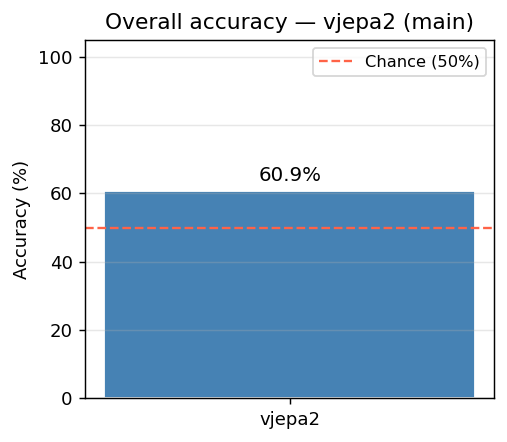

In [30]:
# ---------------------------------------------------------------------------
# Accuracy — overall
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(4, 3.5))
bar = ax.bar([MODEL_NAME], [overall], color="steelblue", edgecolor="white")
ax.axhline(50, color="tomato", linestyle="--", linewidth=1.3, label="Chance (50%)")
ax.set_ylim(0, 105)
ax.set_ylabel("Accuracy (%)")
ax.set_title(f"Overall accuracy — {MODEL_NAME} ({DATASET.split('-')[-1]})")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.text(bar[0].get_x() + bar[0].get_width()/2, overall + 1.5,
        f"{overall:.1f}%", ha="center", va="bottom", fontsize=11)
plt.tight_layout()
savefig(fig, "accuracy_overall")
plt.show()

In [31]:
def bootstrap_accuracy(scene_acc, group_col, n_bootstrap=1000, ci=95):
    """Bootstrap confidence intervals for accuracy grouped by a metadata column.

    Samples scenes with replacement n_bootstrap times and recomputes accuracy
    per group value each time.

    Parameters
    ----------
    scene_acc    : DataFrame with columns [SceneIndex, correct, <group_col>, ...]
    group_col    : str — column to group by (e.g. "condition", "Difficulty", "Cam")
    n_bootstrap  : int — number of bootstrap resamples
    ci           : float — confidence interval width (e.g. 95 for 95% CI)

    Returns
    -------
    DataFrame with columns: <group_col>, mean_acc, ci_lo, ci_hi, n_scenes
    """
    lo = (100 - ci) / 2
    hi = 100 - lo
    group_vals = scene_acc[group_col].unique()
    records = []

    for val in group_vals:
        subset = scene_acc[scene_acc[group_col] == val]["correct"].values
        if len(subset) == 0:
            continue
        boot_means = [
            np.random.choice(subset, size=len(subset), replace=True).mean()
            for _ in range(n_bootstrap)
        ]
        print(boot_means)
        records.append({
            group_col:  val,
            "mean_acc": subset.mean() * 100,
            "ci_lo":    np.percentile(boot_means, lo) * 100,
            "ci_hi":    np.percentile(boot_means, hi) * 100,
            "n_scenes": len(subset),
        })

    return pd.DataFrame(records).sort_values("mean_acc", ascending=False).reset_index(drop=True)


def plot_bootstrap_accuracy(scene_acc, group_col, n_bootstrap=1000, ci=95):
    """Bar chart with bootstrapped CI error bars."""
    df  = bootstrap_accuracy(scene_acc, group_col, n_bootstrap, ci)
    xs  = range(len(df))
    err_lo = df["mean_acc"] - df["ci_lo"]
    err_hi = df["ci_hi"]    - df["mean_acc"]

    fig, ax = plt.subplots(figsize=(max(5, len(df) * 1.2), 4))
    ax.bar(xs, df["mean_acc"], color="steelblue", edgecolor="white",
           yerr=[err_lo, err_hi], capsize=0, error_kw={"linewidth": 1.5, "color": "black"})
    ax.axhline(50, color="tomato", linestyle="--", linewidth=1.3, label="Chance (50%)")
    ax.set_xticks(list(xs))
    ax.set_xticklabels(
        [f"{row[group_col]}\nn={row['n_scenes']}" for _, row in df.iterrows()],
        rotation=30, ha="right", fontsize=9,
    )
    ax.set_ylim(0, 115)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(f"{MODEL_NAME} — accuracy by {group_col}  ({ci}% CI, {n_bootstrap} bootstrap samples)")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    savefig(fig, f"accuracy_{group_col}_bootstrap")
    plt.show()
    return df

In [32]:
bootstrap_accuracy(scene_acc, 'condition', n_bootstrap=2, ci=95)

[np.float64(0.7534246575342466), np.float64(0.7123287671232876)]
[np.float64(0.65), np.float64(0.65)]
[np.float64(0.6), np.float64(0.45)]
[np.float64(0.43333333333333335), np.float64(0.5666666666666667)]


,condition,mean_acc,ci_lo,ci_hi,n_scenes
0,solidity,69.863014,71.335616,75.239726,73
1,continuity,63.333333,65.000000,65.000000,60
2,immutability,60.000000,45.375000,59.625000,60
3,permanence,48.333333,43.666667,56.333333,60


[np.float64(0.7123287671232876), np.float64(0.6986301369863014), np.float64(0.6986301369863014), np.float64(0.7397260273972602), np.float64(0.726027397260274), np.float64(0.6027397260273972), np.float64(0.6438356164383562), np.float64(0.7397260273972602), np.float64(0.7534246575342466), np.float64(0.6301369863013698), np.float64(0.726027397260274), np.float64(0.726027397260274), np.float64(0.6986301369863014), np.float64(0.7534246575342466), np.float64(0.726027397260274), np.float64(0.7397260273972602), np.float64(0.6712328767123288), np.float64(0.6575342465753424), np.float64(0.6986301369863014), np.float64(0.6301369863013698), np.float64(0.7123287671232876), np.float64(0.863013698630137), np.float64(0.7534246575342466), np.float64(0.684931506849315), np.float64(0.7123287671232876), np.float64(0.7671232876712328), np.float64(0.7123287671232876), np.float64(0.7671232876712328), np.float64(0.7397260273972602), np.float64(0.684931506849315), np.float64(0.7123287671232876), np.float64(0.6

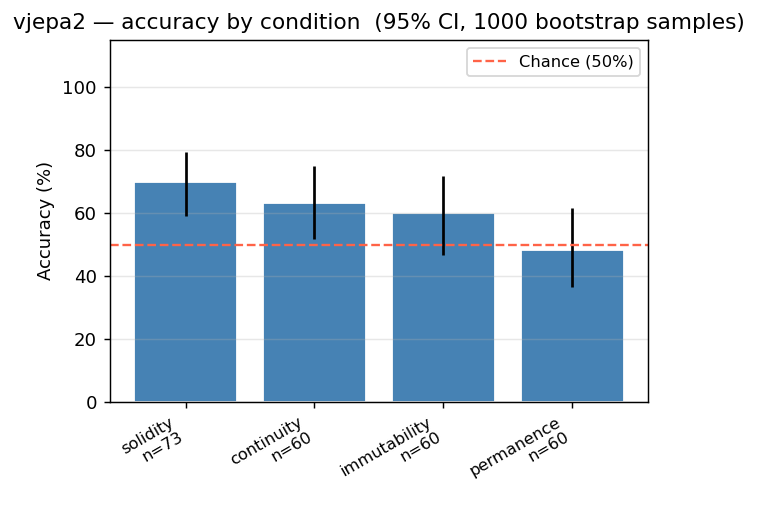

[np.float64(0.6923076923076923), np.float64(0.5384615384615384), np.float64(0.6153846153846154), np.float64(0.6923076923076923), np.float64(0.7692307692307693), np.float64(0.46153846153846156), np.float64(0.46153846153846156), np.float64(0.5769230769230769), np.float64(0.7307692307692307), np.float64(0.5384615384615384), np.float64(0.5384615384615384), np.float64(0.7307692307692307), np.float64(0.5), np.float64(0.5769230769230769), np.float64(0.5769230769230769), np.float64(0.7307692307692307), np.float64(0.6153846153846154), np.float64(0.6923076923076923), np.float64(0.6153846153846154), np.float64(0.46153846153846156), np.float64(0.6538461538461539), np.float64(0.6153846153846154), np.float64(0.8461538461538461), np.float64(0.5769230769230769), np.float64(0.6153846153846154), np.float64(0.6538461538461539), np.float64(0.6153846153846154), np.float64(0.7307692307692307), np.float64(0.6923076923076923), np.float64(0.46153846153846156), np.float64(0.6153846153846154), np.float64(0.65384

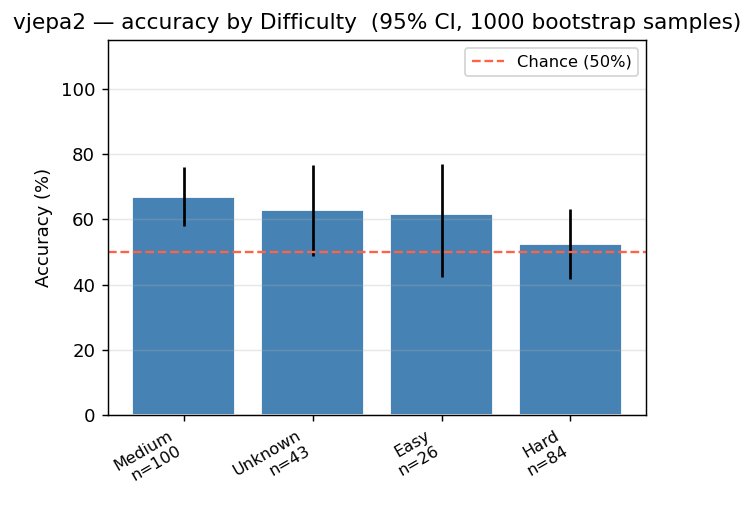

[np.float64(0.5673076923076923), np.float64(0.5673076923076923), np.float64(0.4326923076923077), np.float64(0.5096153846153846), np.float64(0.5384615384615384), np.float64(0.6057692307692307), np.float64(0.5384615384615384), np.float64(0.5769230769230769), np.float64(0.6538461538461539), np.float64(0.6057692307692307), np.float64(0.5865384615384616), np.float64(0.5096153846153846), np.float64(0.5769230769230769), np.float64(0.5384615384615384), np.float64(0.5769230769230769), np.float64(0.5096153846153846), np.float64(0.6153846153846154), np.float64(0.5384615384615384), np.float64(0.5961538461538461), np.float64(0.5961538461538461), np.float64(0.5673076923076923), np.float64(0.6346153846153846), np.float64(0.6346153846153846), np.float64(0.5288461538461539), np.float64(0.5865384615384616), np.float64(0.625), np.float64(0.5865384615384616), np.float64(0.6634615384615384), np.float64(0.5), np.float64(0.5961538461538461), np.float64(0.625), np.float64(0.5480769230769231), np.float64(0.576

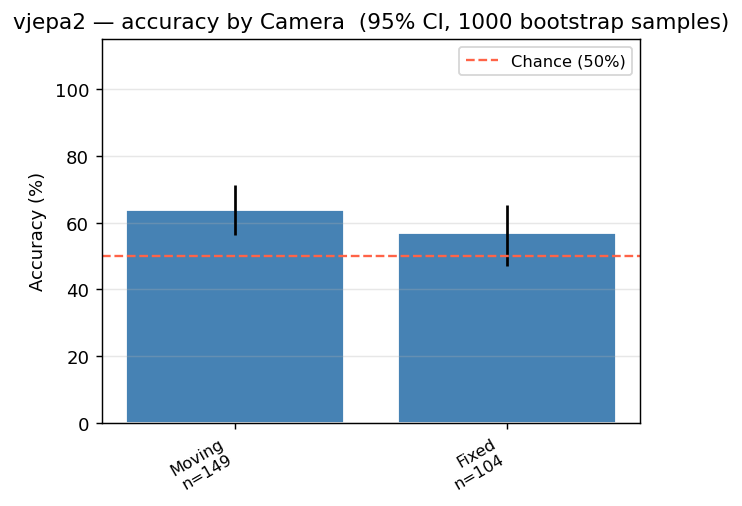

In [35]:
GROUP_COLS = ["condition", "Difficulty", "Camera"] # "env", "game_name",

for group in GROUP_COLS:
    plot_bootstrap_accuracy(scene_acc, group, n_bootstrap=1000, ci=95)

In [36]:

# Scene to plot in the surprise-over-time section
SCENE_IDX   = 10              # set to an integer SceneIndex, or None to use the first scene
CTX_IDX     = 2 # 0                 # index into context_lengths list saved in the .pth

# Sliding window stride — matches stride_sliding_window in the yaml config
STRIDE      = 2                 # windows are spaced this many sampled frames apart

# ---------------------------------------------------------------------------
# Surprise over time — set SCENE_IDX and CTX_IDX in the config cell
# ---------------------------------------------------------------------------

scene_idx  = SCENE_IDX if SCENE_IDX is not None else int(results_df["SceneIndex"].iloc[0])
ctx_idx    = CTX_IDX
ctx_len    = ctx_lengths[ctx_idx]
frame_step = meta.get("frame_step", 1)

scene_df  = results_df[results_df["SceneIndex"] == str(scene_idx)]
scene_row = scene_df[["condition", "Difficulty", "game_name"]].iloc[0]
palette   = {1: "#3a86ff", 0: "#e63946"}

Saved: ./figures/vjepa2_surprise_scene10_all_ctx.png


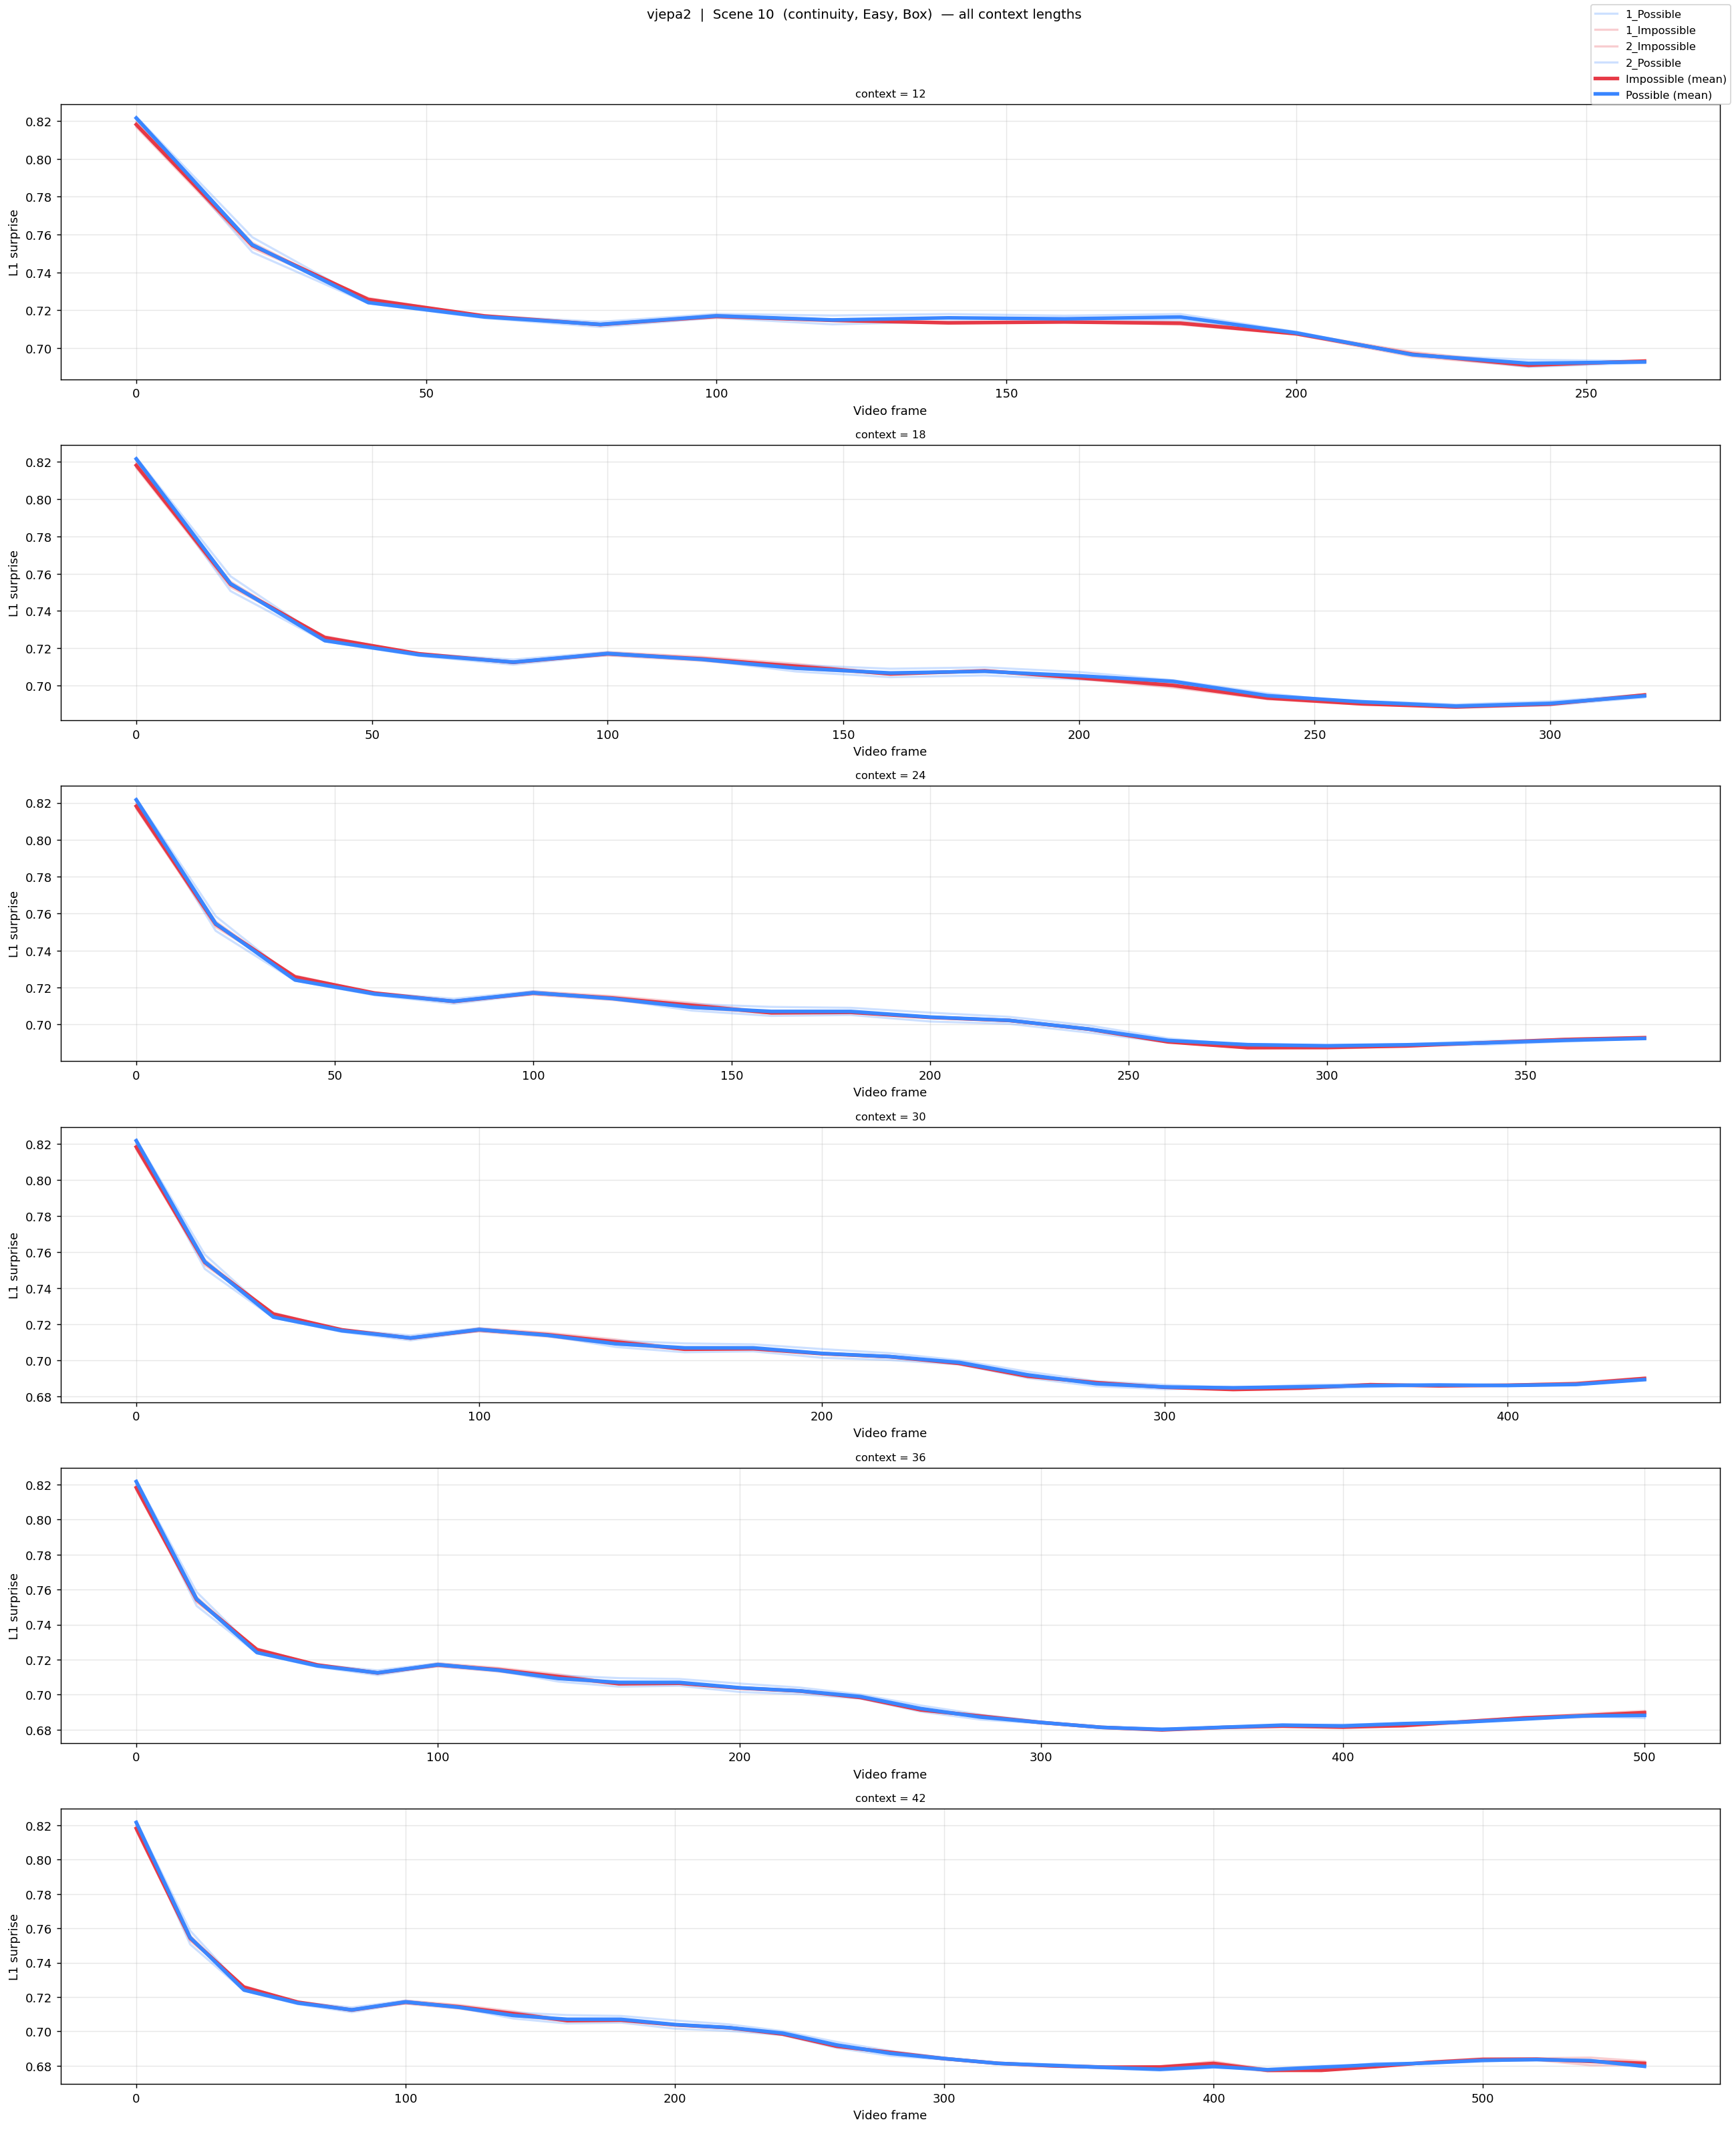

In [37]:
# ---------------------------------------------------------------------------
# Surprise over time — all context lengths for the selected scene
# ---------------------------------------------------------------------------

n_ctx = len(ctx_lengths)
fig, axes = plt.subplots(n_ctx, 1, figsize=(20, 4 * n_ctx), squeeze=False)

for i, (c_len, ax) in enumerate(zip(ctx_lengths, axes.flatten())):
    traces_by_target = {0: [], 1: []}

    for _, row in scene_df.iterrows():
        vidx  = int(row["video_idx"])
        trace = losses[vidx, i, :].numpy()
        nz    = np.where(trace > 0)[0]
        if len(nz) == 0:
            continue
        trace  = trace[: nz[-1] + 1]
        frames = np.arange(len(trace)) * STRIDE * frame_step
        color  = palette.get(row["target"], "gray")
        ax.plot(frames, trace, color=color, linewidth=1.8, alpha=0.25,
                label=row["type"] if i == 0 else "_")
        if row["target"] in traces_by_target:
            traces_by_target[row["target"]].append(trace)

    for target, traces in traces_by_target.items():
        if not traces:
            continue
        max_len    = max(len(t) for t in traces)
        padded     = np.array([np.pad(t, (0, max_len - len(t))) for t in traces])
        mask       = padded > 0
        avg        = np.where(mask.sum(0) > 0, (padded * mask).sum(0) / mask.sum(0).clip(1), np.nan)
        avg_frames = np.arange(max_len) * STRIDE * frame_step
        color      = palette[target]
        label      = f"{'Possible' if target == 1 else 'Impossible'} (mean)"
        ax.plot(avg_frames, avg, color=color, linewidth=3, alpha=1.0, label=label if i == 0 else "_")

    ax.set_title(f"context = {c_len}", fontsize=9)
    ax.set_xlabel("Video frame")
    ax.set_ylabel("L1 surprise")
    ax.grid(alpha=0.3)

handles, labels = axes.flatten()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=9)
fig.suptitle(
    f"{MODEL_NAME}  |  Scene {scene_idx}  "
    f"({scene_row['condition']}, {scene_row['Difficulty']}, {scene_row['game_name']})  — all context lengths",
    fontsize=11,
   y=1.02,
)
plt.tight_layout(rect=[0, 0, 1, 1.0])
savefig(fig, f"surprise_scene{scene_idx}_all_ctx")
plt.show()

In [ ]:
# fig, ax = plt.subplots(figsize=(20, 6))

# traces_by_target = {0: [], 1: []}

# for _, row in scene_df.iterrows():
#     vidx   = int(row["video_idx"])
#     trace  = losses[vidx, ctx_idx, :].numpy()
#     nz     = np.where(trace > 0)[0]
#     if len(nz) == 0:
#         continue
#     trace  = trace[: nz[-1] + 1]
#     frames = np.arange(len(trace)) * STRIDE * frame_step
#     color  = palette.get(row["target"], "gray")
#     label  = f"{row['type']} — {os.path.basename(str(row['file_name']))}"
#     ax.plot(frames, trace, color=color, linewidth=2, alpha=0.25, label=label)
#     if row["target"] in traces_by_target:
#         traces_by_target[row["target"]].append(trace)

# # Plot averages — pad traces to same length before averaging
# for target, traces in traces_by_target.items():
#     if not traces:
#         continue
#     max_len    = max(len(t) for t in traces)
#     padded     = np.array([np.pad(t, (0, max_len - len(t))) for t in traces])
#     mask       = padded > 0
#     avg        = np.where(mask.sum(0) > 0, (padded * mask).sum(0) / mask.sum(0).clip(1), np.nan)
#     avg_frames = np.arange(max_len) * STRIDE * frame_step
#     color      = palette[target]
#     label      = f"{'Possible' if target == 1 else 'Impossible'} (mean)"
#     ax.plot(avg_frames, avg, color=color, linewidth=3, alpha=1.0, label=label)

# ax.set_title(
#     f"{MODEL_NAME}  |  Scene {scene_idx}  "
#     f"({scene_row['condition']}, {scene_row['Difficulty']}, {scene_row['game_name']})  "
#     f"|  context = {ctx_len}"
# )
# ax.set_xlabel(f"Video frame  (sampled every {frame_step} frames, stride={STRIDE})")
# ax.set_ylabel("Surprise")
# ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
# ax.grid(alpha=0.3)
# plt.tight_layout()
# savefig(fig, f"surprise_scene{scene_idx}_ctx{ctx_len}")
# plt.show()

In [93]:
# ---------------------------------------------------------------------------
# Surprise over time — all context lengths for the selected scene
# ---------------------------------------------------------------------------

# n_ctx = len(ctx_lengths)
# ncols = min(n_ctx, 3)
# nrows = (n_ctx + ncols - 1) // ncols
# fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows), squeeze=False)

# for i, (c_len, ax) in enumerate(zip(ctx_lengths, axes.flatten())):
#     for _, row in scene_df.iterrows():
#         vidx  = int(row["video_idx"])
#         trace = losses[vidx, i, :].numpy()
#         nz    = np.where(trace > 0)[0]
#         if len(nz) == 0:
#             continue
#         trace  = trace[: nz[-1] + 1]
#         frames = np.arange(len(trace)) * STRIDE * frame_step
#         color  = palette.get(row["target"], "gray")
#         ax.plot(frames, trace, color=color, linewidth=1.8, alpha=0.9,
#                 label=row["type"] if i == 0 else "_")
#     ax.set_title(f"context = {c_len}", fontsize=9)
#     ax.set_xlabel("Video frame")
#     ax.set_ylabel("L1 surprise")
#     ax.grid(alpha=0.3)

# for ax in axes.flatten()[n_ctx:]:
#     ax.set_visible(False)

# handles, labels = axes.flatten()[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper right", fontsize=9)
# fig.suptitle(
#     f"{MODEL_NAME}  |  Scene {scene_idx}  "
#     f"({scene_row['condition']}, {scene_row['Difficulty']}, {scene_row['game_name']}) — all context lengths",
#     fontsize=11, y=1.01,
# )
# plt.tight_layout()
# savefig(fig, f"surprise_scene{scene_idx}_all_ctx")
# plt.show()